<a href="https://colab.research.google.com/github/messias-antonio-analytics/Messias-Data-Analysis-Portfolio/blob/main/KoboToolbox%20Data%20Automation%20and%20Analytics%20with%20Python%20API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[2026-08-19 09:55:26.633014] 🚀 Conectando ao KoboToolbox...
✅ 8 submissões carregadas.

📊 GERANDO GRÁFICOS PARA TODOS OS INDICADORES (8 famílias)
📁 Pasta de Saída: relatorio_onu_completo_20260819_095526/

👨‍👩‍👧‍👦 A. DEMOGRAFIA E DEFICIÊNCIA (DEMOGRAPHICS & PWD)
   💾 relatorio_onu_completo_20260819_095526/demografia_faixa_etaria.png


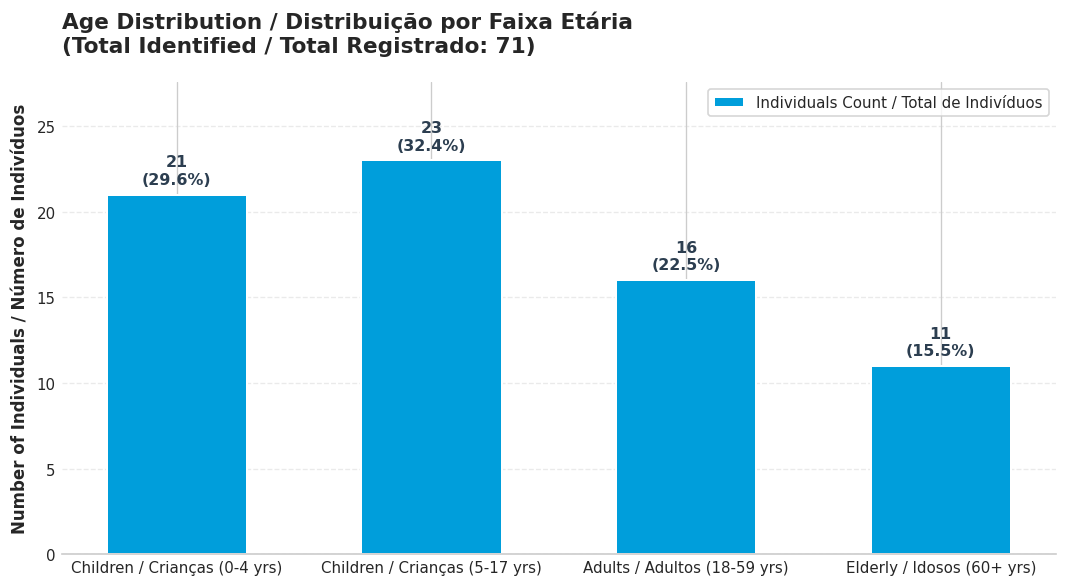

   💾 relatorio_onu_completo_20260819_095526/demografia_pessoas_com_deficiencia.png


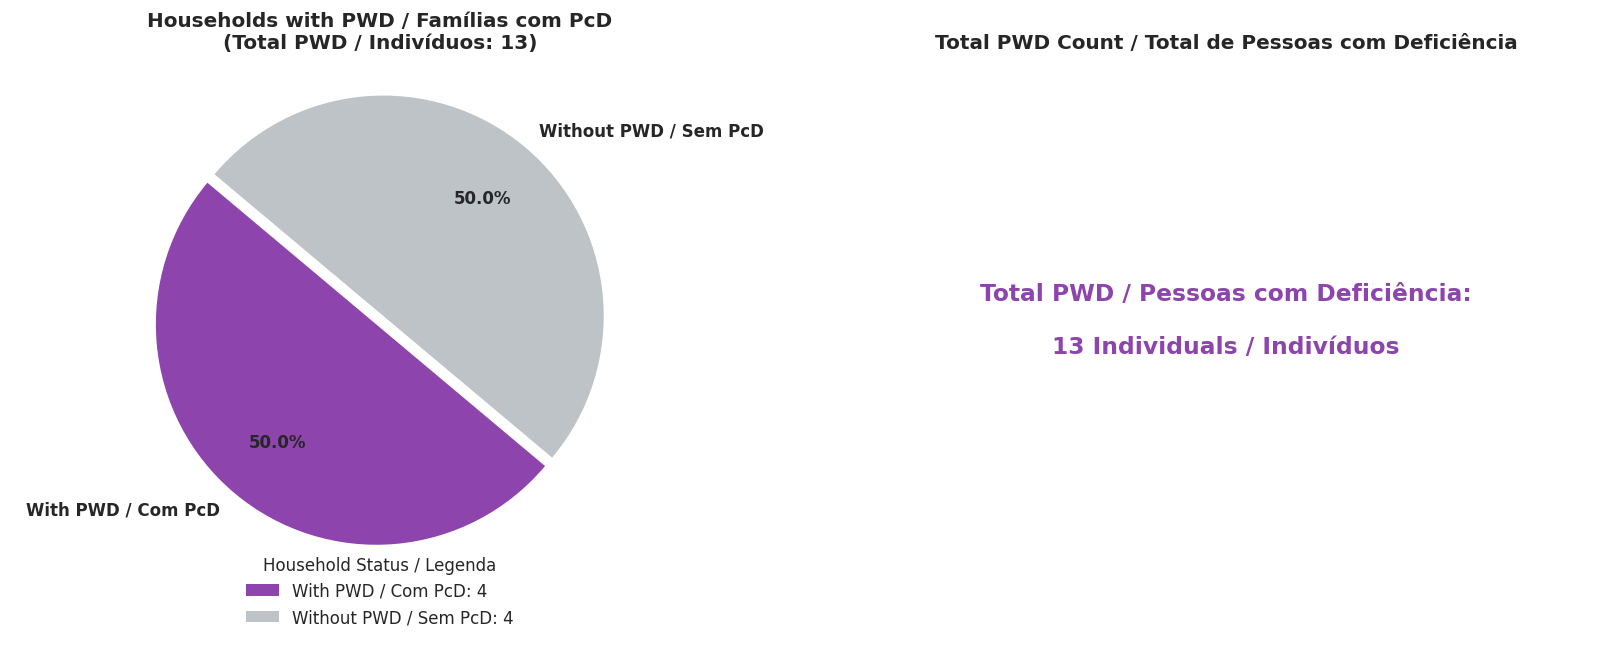


📍 B. GEOGRAFIA E IDENTIFICAÇÃO (LOCATION & RESPONDENT)
   💾 relatorio_onu_completo_20260819_095526/Residencial_Zone___Zona_de_Residência.png


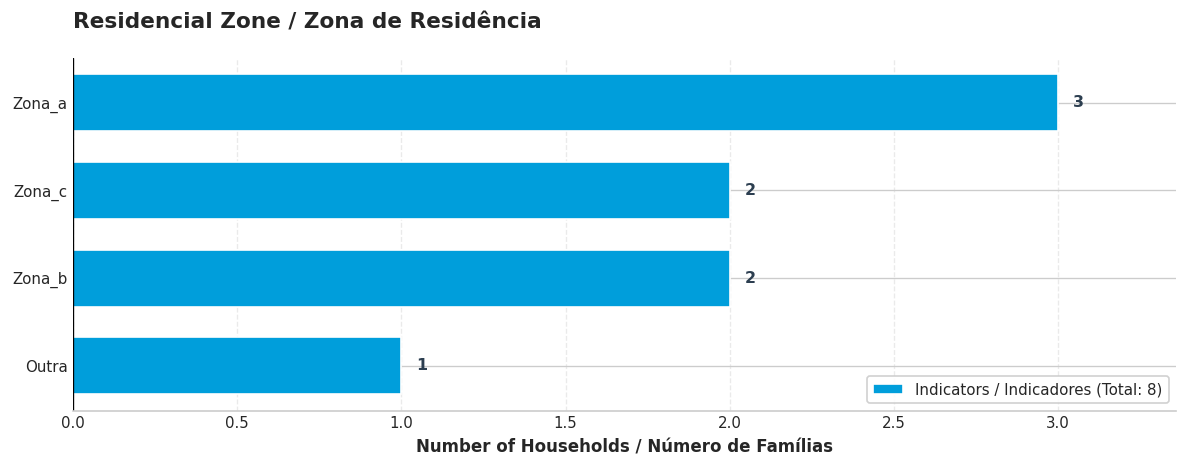

   💾 relatorio_onu_completo_20260819_095526/Landmark___Ponto_de_Referência.png


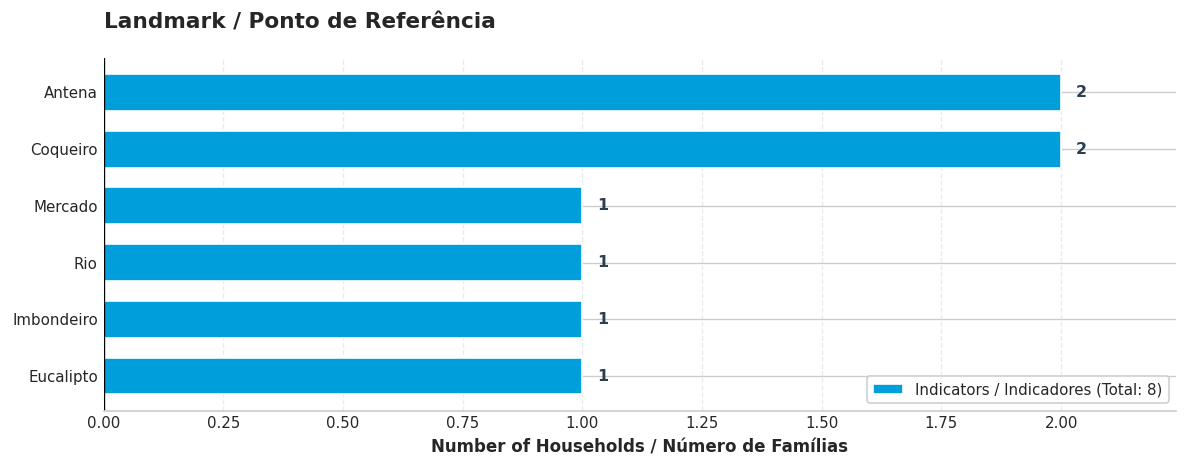

   💾 relatorio_onu_completo_20260819_095526/Respondent_Type___Tipo_de_Respondente.png


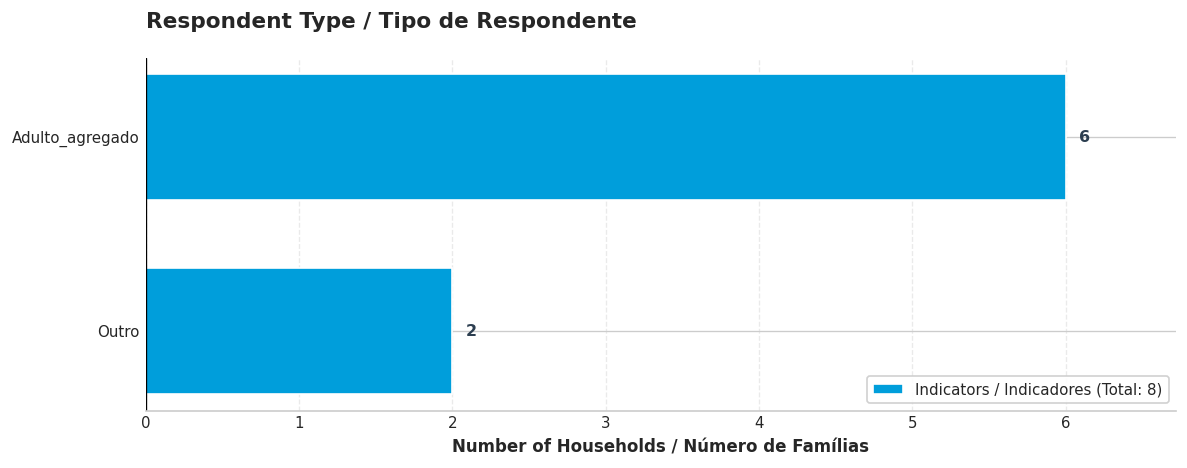


🚶 C. DESLOCAMENTO (DISPLACEMENT)
   ⚠️ Sem dados para: Displaced Households / Famílias Deslocadas
   💾 relatorio_onu_completo_20260819_095526/distribuicao_meses_deslocado.png


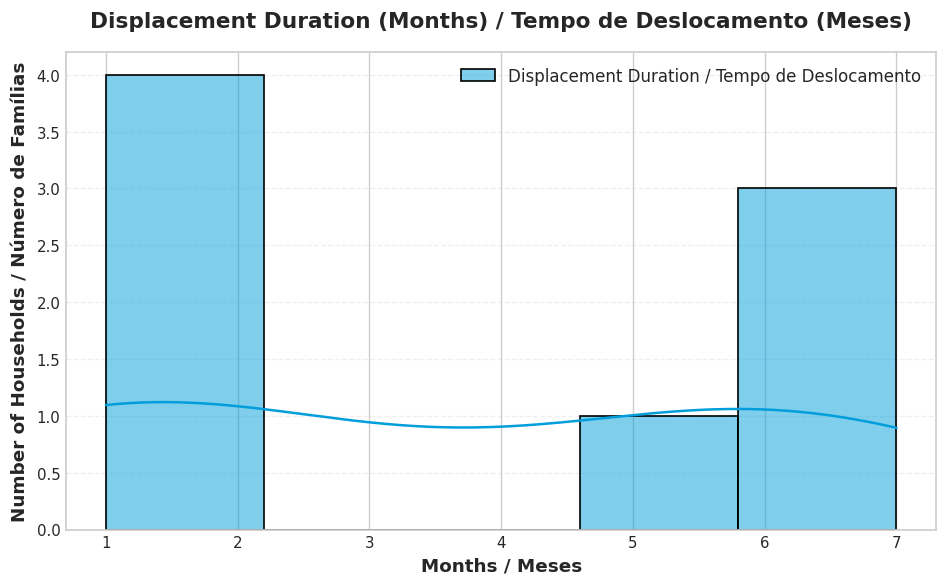


🛡️ D. PROTEÇÃO E RISCOS (PROTECTION & RISKS)
   ⚠️ Nenhuma resposta múltipla para: Protection Risks / Riscos de Proteção
   💾 relatorio_onu_completo_20260819_095526/Safety_Perception___Percepção_de_Segurança.png


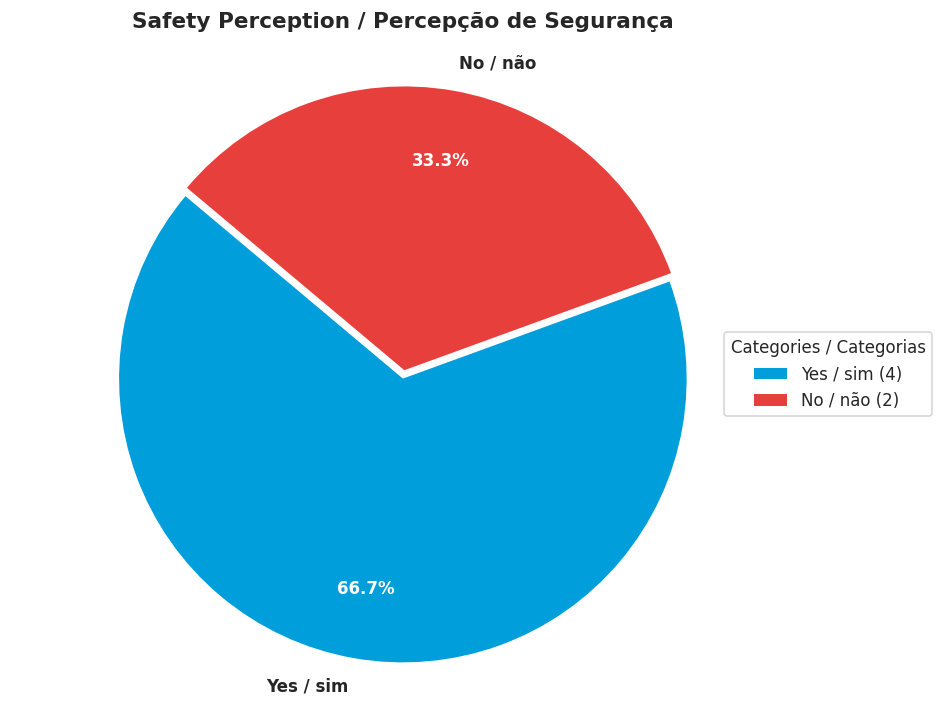


🏥 E. SAÚDE (HEALTH)
   ⚠️ Nenhuma resposta múltipla para: Health Needs / Necessidades de Saúde
   💾 relatorio_onu_completo_20260819_095526/Access_to_Health_Services___Acesso_à_Saúde.png


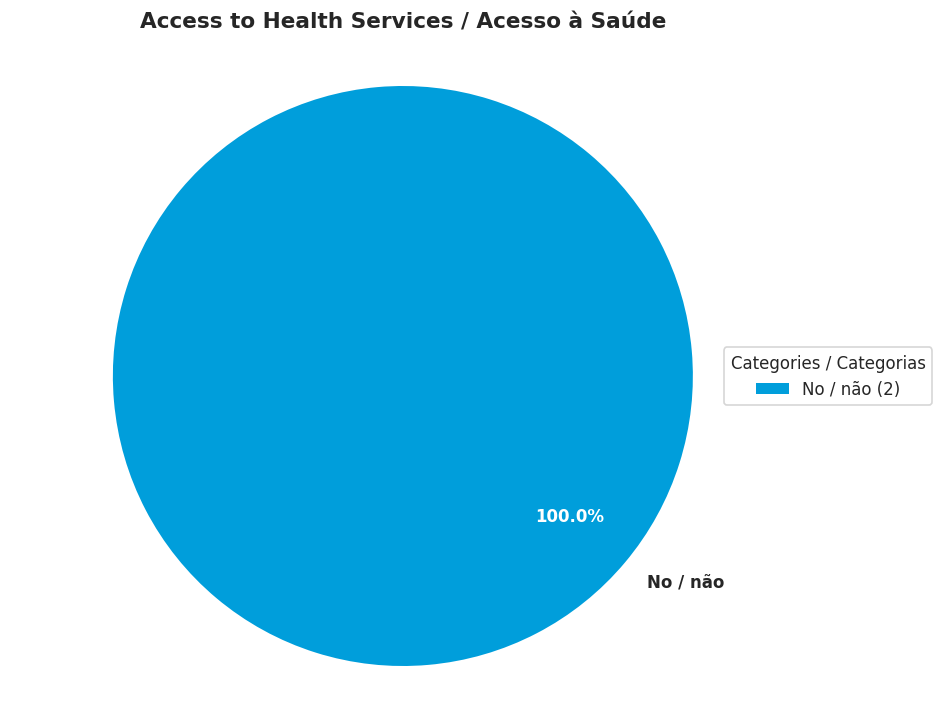

   ⚠️ Nenhuma resposta múltipla para: Healthcare Barriers / Barreiras de Acesso

💧 F. WASH
   💾 relatorio_onu_completo_20260819_095526/Water_Source___Fonte_de_Água.png


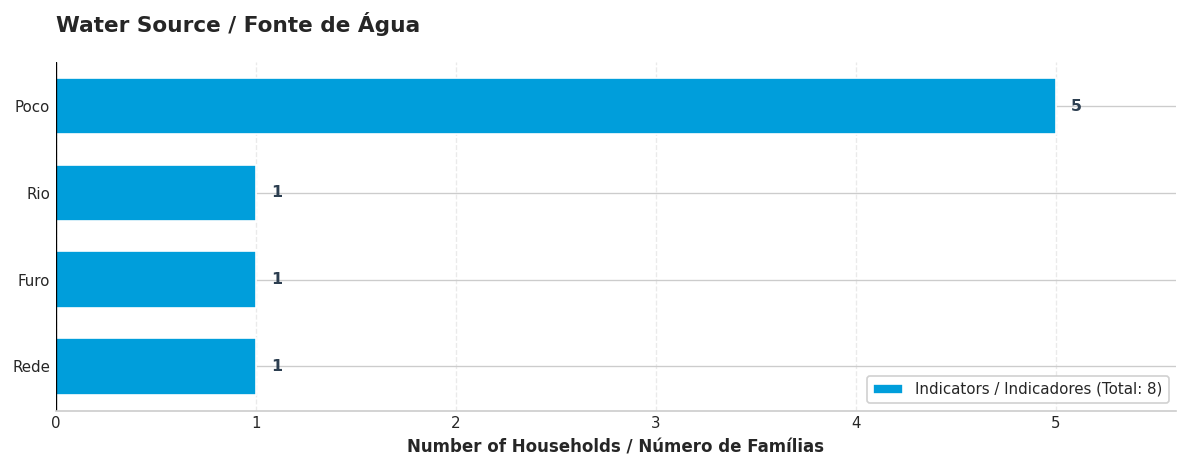

   💾 relatorio_onu_completo_20260819_095526/Water_Quality___Qualidade_da_Água.png


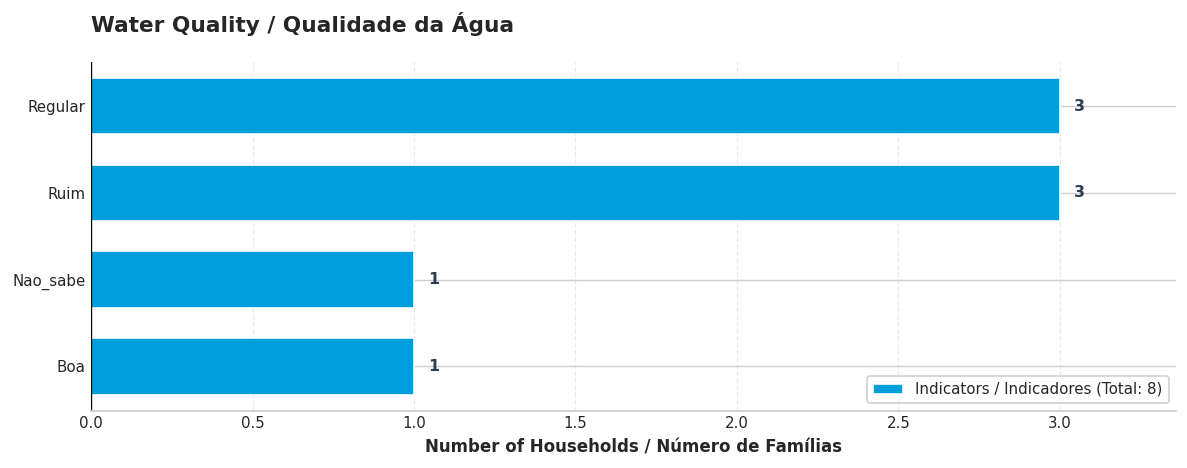

   💾 relatorio_onu_completo_20260819_095526/Latrine_Availability___Disponibilidade_de_Latrina.png


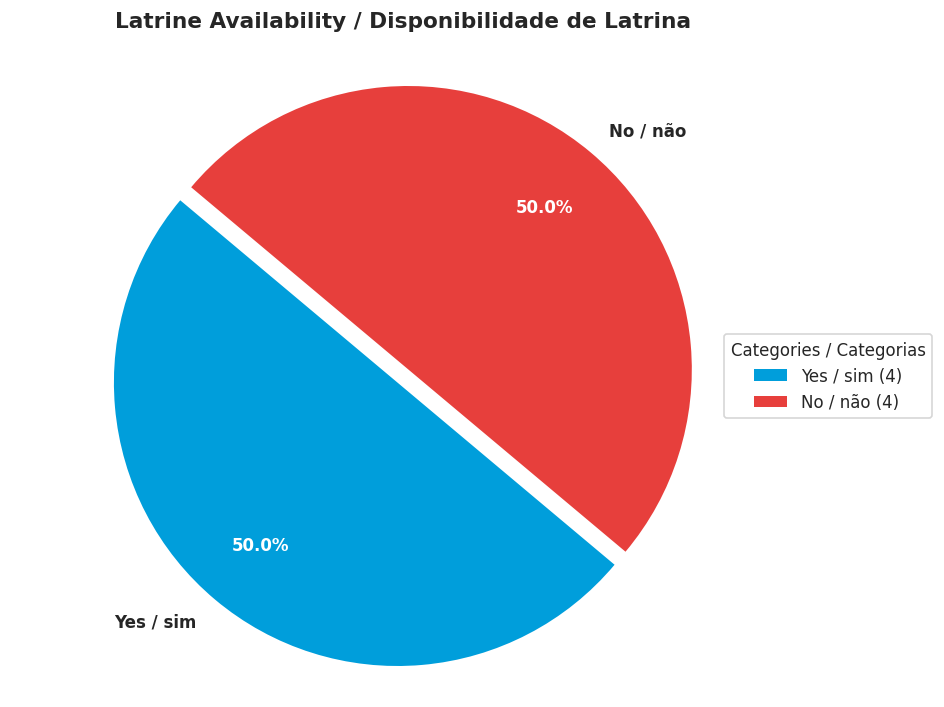


🍽️ G. SEGURANÇA ALIMENTAR (FOOD SECURITY)
   💾 relatorio_onu_completo_20260819_095526/Food_Availability___Disponibilidade_de_Alimentos.png


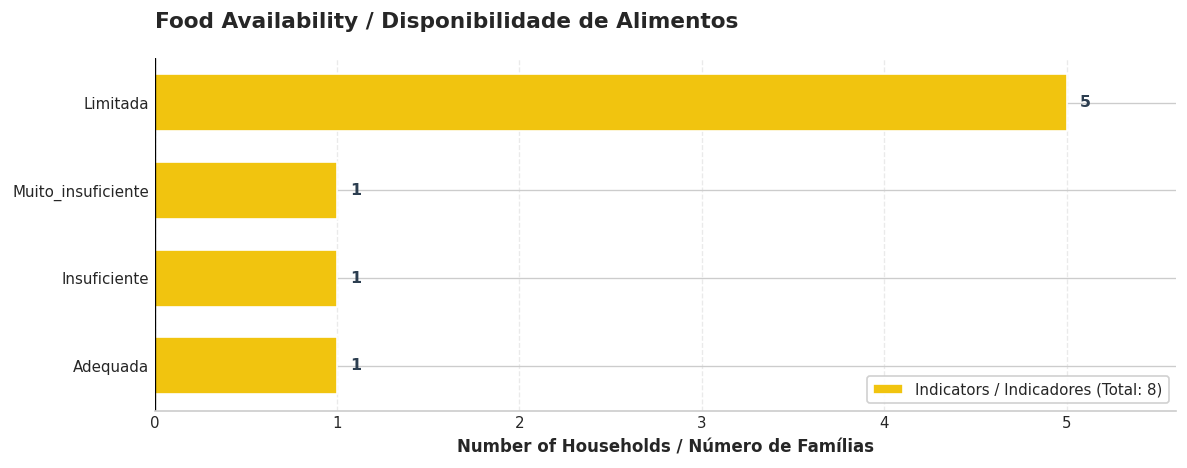

   ⚠️ Nenhuma resposta múltipla para: Coping Strategies / Estratégias de Enfrentamento

🏠 H. ABRIGO (SHELTER)
   💾 relatorio_onu_completo_20260819_095526/Shelter_Type___Tipo_de_Abrigo.png


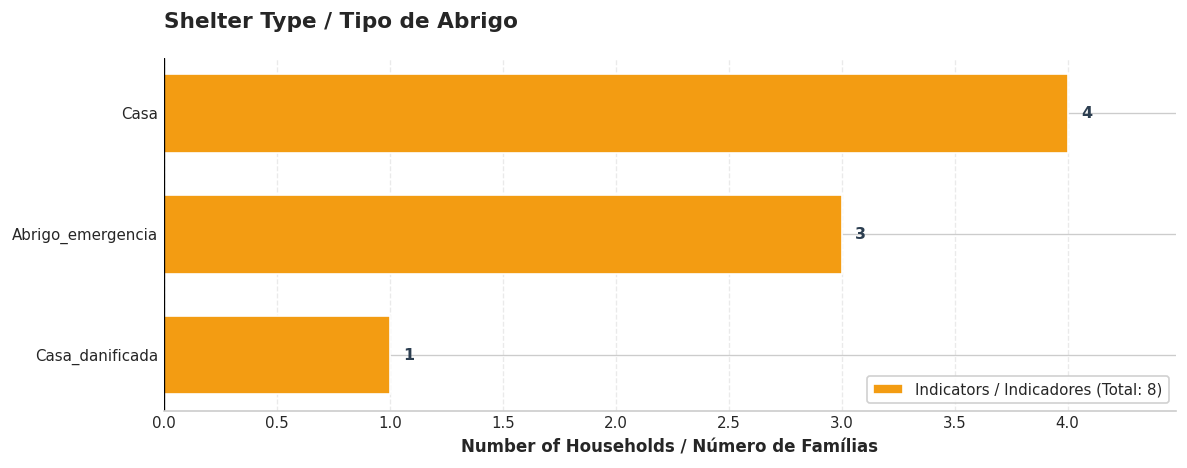

   ⚠️ Nenhuma resposta múltipla para: Shelter Needs / Necessidades de Abrigo

💰 I. MEIOS DE VIDA (LIVELIHOODS)
   ⚠️ Nenhuma resposta múltipla para: Income Sources / Fontes de Renda
   ⚠️ Nenhuma resposta múltipla para: Economic Needs / Necessidades Econômicas

🎯 J. PRIORIDADES (PRIORITIES & REFERRALS)
   ⚠️ Nenhuma resposta múltipla para: Top Priorities / Principais Prioridades
   💾 relatorio_onu_completo_20260819_095526/Urgency_Level___Nível_de_Urgência.png


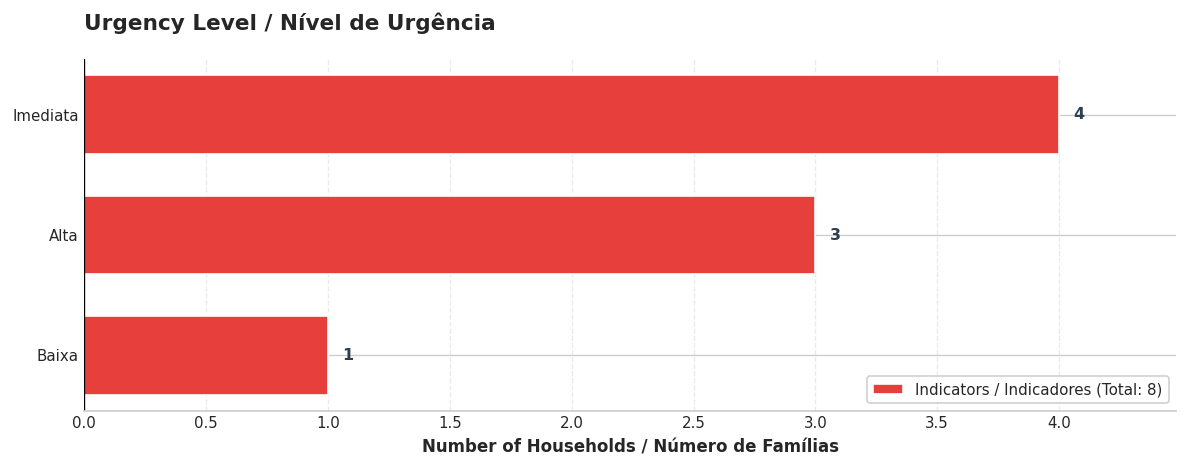


✅ RELATÓRIO COMPLETO COM LEGENDAS EM INGLÊS GERADO COM SUCESSO!
📁 Todos os gráficos salvos em: relatorio_onu_completo_20260819_095526/
📁 Dados brutos salvos em: relatorio_onu_completo_20260819_095526/dados_brutos.csv


In [9]:
import os
import re
import requests
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter

# ==========================================
# ⚙️ CONFIGURAÇÕES (TOKEN E API KOBO)
# ==========================================
TOKEN = "69326573ae15d0ba5b42295ec2c460e18078096e"
UID = "ab9VBKFmKxwHn4tCYu8ZgH"
URL_API = "https://kf.kobotoolbox.org/api/v2"
PASTA_SAIDA = f"relatorio_onu_completo_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

# Paleta de Cores Padrão Humanitário / ONU
CORES_SETORES = {
    'Saúde': '#E73F3C',
    'WASH': '#009EDB',
    'Abrigo': '#F39C12',
    'Alimentação': '#F1C40F',
    'Proteção': '#8E44AD',
    'Educação': '#1ABC9C',
    'Logística': '#2C3E50',
    'Default': '#009EDB'
}
PALETA_ONU = ['#009EDB', '#E73F3C', '#F39C12', '#2C3E50', '#27AE60', '#8E44AD', '#F1C40F', '#1ABC9C']

def configurar_estilo_onu():
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
    plt.rcParams['font.size'] = 10
    plt.rcParams['axes.titlesize'] = 13
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['axes.labelsize'] = 11
    plt.rcParams['xtick.labelsize'] = 9
    plt.rcParams['ytick.labelsize'] = 9
    plt.rcParams['figure.dpi'] = 120
    plt.rcParams['savefig.dpi'] = 200

configurar_estilo_onu()

# ==========================================
# 1. FUNÇÕES AUXILIARES E TRATAMENTO
# ==========================================

def normalizar_texto(texto):
    """
    Normaliza strings removendo espaços extras e padronizando maiúsculas/minúsculas.
    """
    if pd.isna(texto) or texto is None:
        return None

    texto = str(texto).strip()
    texto = "".join(ch for ch in texto if unicodedata.category(ch)[0] != "C")

    if not texto:
        return None

    texto_lower = texto.lower()
    if texto_lower in ['sim', 'yes', 'true', '1', 'on']:
        return 'Yes / Sim'
    if texto_lower in ['nao', 'não', 'no', 'false', '0', 'off']:
        return 'No / Não'

    return texto.strip().capitalize()

def buscar_dados_kobo():
    headers = {"Authorization": f"Token {TOKEN}"}
    url = f"{URL_API}/assets/{UID}/data/"
    todos = []
    while url:
        resp = requests.get(url, headers=headers)
        if resp.status_code != 200:
            raise Exception(f"Erro {resp.status_code}: {resp.text}")
        dados = resp.json()
        todos.extend(dados.get("results", []))
        url = dados.get("next")
    return todos

def encontrar_coluna(df, padroes):
    """Encontra o nome exato da coluna que corresponde a um dos padrões."""
    for padrao in padroes:
        if padrao in df.columns:
            return padrao
        for col in df.columns:
            if re.search(r'\b' + re.escape(padrao) + r'\b', col, re.IGNORECASE) or col.endswith('/' + padrao):
                return col
    return None

def contar_multiplas(df, prefixo):
    """Conta frequências em perguntas select_multiple limpando rótulos."""
    contagem = Counter()
    prefixo_limpo = prefixo.rstrip('/') + '/'
    cols = [c for c in df.columns if c.startswith(prefixo_limpo)]

    if not cols:
        prefixo_sem_barra = prefixo.rstrip('/')
        cols = [c for c in df.columns if c.startswith(prefixo_sem_barra + '/')]

    for col in cols:
        nome_opcao = col.split('/')[-1]
        nome_opcao_norm = normalizar_texto(nome_opcao.replace('_', ' '))

        if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == 'bool':
            total = df[col].sum()
            if total > 0:
                contagem[nome_opcao_norm] += int(total)
        else:
            for val in df[col].dropna():
                val_norm = normalizar_texto(val)
                if val_norm in ['Yes / Sim', '1', 'True']:
                    contagem[nome_opcao_norm] += 1
    return contagem

# ==========================================
# 2. FUNÇÕES DE GRÁFICOS GERAIS COM LEGENDA EM INGLÊS
# ==========================================

def grafico_barras_onu(dados, titulo, xlabel_pt="Número de Famílias", xlabel_en="Number of Households", cor=None, salvar=True, mostrar=True, nome_arquivo=None):
    if dados is None:
        print(f"   ⚠️ Sem dados para: {titulo}")
        return

    if isinstance(dados, pd.Series):
        items = [(normalizar_texto(k), v) for k, v in dados.items() if v > 0]
    elif isinstance(dados, dict):
        items = [(normalizar_texto(k), v) for k, v in dados.items() if v > 0]
    else:
        try:
            items = [(normalizar_texto(k), v) for k, v in dict(dados).items() if v > 0]
        except:
            print(f"   ⚠️ Dados inválidos para: {titulo}")
            return

    agrupado = Counter()
    for k, v in items:
        if k is not None:
            agrupado[k] += v

    if not agrupado:
        print(f"   ⚠️ Sem dados positivos para: {titulo}")
        return

    items_ordenados = sorted(agrupado.items(), key=lambda x: x[1], reverse=False)
    labels, values = zip(*items_ordenados)

    fig, ax = plt.subplots(figsize=(10, max(4, len(labels) * 0.55)))
    cor_usada = cor or CORES_SETORES['Default']
    bars = ax.barh(labels, values, color=cor_usada, edgecolor='white', height=0.65, linewidth=1, label=f"Indicators / Indicadores (Total: {sum(values)})")

    max_val = max(values) if values else 1
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + (max_val * 0.015), bar.get_y() + bar.get_height()/2,
                f'{int(val)}', va='center', ha='left', fontsize=9.5, fontweight='bold', color='#2C3E50')

    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=18, loc='left')
    ax.set_xlabel(f"{xlabel_en} / {xlabel_pt}", fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_xlim(0, max_val * 1.12)

    # Adiciona Legenda em Inglês/Português
    ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

    plt.tight_layout()

    if salvar:
        nome = nome_arquivo or re.sub(r'[^\w]', '_', titulo).strip('_')[:50] + '.png'
        caminho = os.path.join(PASTA_SAIDA, nome)
        plt.savefig(caminho, dpi=200, bbox_inches='tight')
        print(f"   💾 {caminho}")
    if mostrar:
        plt.show()
    else:
        plt.close()

def grafico_pizza_onu(dados, titulo, salvar=True, mostrar=True, nome_arquivo=None):
    if dados is None:
        print(f"   ⚠️ Sem dados para pizza: {titulo}")
        return

    if isinstance(dados, pd.Series):
        dados = dados.to_dict()

    dados_limpos = Counter()
    for k, v in dados.items():
        k_norm = normalizar_texto(k)
        if k_norm and v > 0:
            dados_limpos[k_norm] += v

    if not dados_limpos:
        print(f"   ⚠️ Sem dados positivos para pizza: {titulo}")
        return

    labels = list(dados_limpos.keys())
    values = list(dados_limpos.values())
    cores = PALETA_ONU[:len(labels)] if len(labels) <= len(PALETA_ONU) else sns.color_palette("Set2", len(labels))
    explode = [0.03 if v == max(values) else 0 for v in values]

    fig, ax = plt.subplots(figsize=(8, 6))
    wedges, texts, autotexts = ax.pie(
        values, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=cores, explode=explode, pctdistance=0.75,
        textprops={'fontsize': 10, 'fontweight': 'bold'}
    )

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(10)

    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=18, loc='center')
    ax.axis('equal')

    # Adiciona Legenda em Inglês/Português
    ax.legend(wedges, [f"{lbl} ({val})" for lbl, val in zip(labels, values)],
              title="Categories / Categorias", loc="center left", bbox_to_anchor=(0.9, 0.5), frameon=True)

    plt.tight_layout()

    if salvar:
        nome = nome_arquivo or re.sub(r'[^\w]', '_', titulo).strip('_')[:50] + '.png'
        caminho = os.path.join(PASTA_SAIDA, nome)
        plt.savefig(caminho, dpi=200, bbox_inches='tight')
        print(f"   💾 {caminho}")
    if mostrar:
        plt.show()
    else:
        plt.close()

# ==========================================
# 3. FUNÇÕES DEMOGRÁFICAS E PCD COM LEGENDA EM INGLÊS
# ==========================================

def grafico_faixas_etarias(dados_faixas, titulo="Demographic Composition / Composição Demográfica", salvar=True, nome_arquivo=None):
    """
    Gera gráfico de barras verticais para faixas etárias com legendas e rótulos em Inglês e Português.
    """
    if not dados_faixas:
        print(f"   ⚠️ Sem dados para: {titulo}")
        return

    labels = list(dados_faixas.keys())
    valores = list(dados_faixas.values())

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(labels, valores, color='#009EDB', edgecolor='white', width=0.55, linewidth=1.2, label='Individuals Count / Total de Indivíduos')

    total_pessoas = sum(valores) if sum(valores) > 0 else 1
    max_val = max(valores) if valores else 1

    for bar, val in zip(bars, valores):
        pct = (val / total_pessoas) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max_val * 0.02),
                f'{int(val)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#2C3E50')

    ax.set_title(f"{titulo}\n(Total Identified / Total Registrado: {total_pessoas})", fontsize=13, fontweight='bold', pad=18, loc='left')
    ax.set_ylabel("Number of Individuals / Número de Indivíduos", fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_ylim(0, max_val * 1.20)

    # Legenda em Inglês
    ax.legend(loc='upper right', frameon=True, facecolor='white', fontsize=9)

    plt.tight_layout()
    if salvar:
        nome = nome_arquivo or re.sub(r'[^\w]', '_', titulo).strip('_')[:50] + '.png'
        caminho = os.path.join(PASTA_SAIDA, nome)
        plt.savefig(caminho, dpi=200, bbox_inches='tight')
        print(f"   💾 {caminho}")
    plt.show()

def grafico_pcd_detalhado(df, salvar=True, nome_arquivo="demografia_pessoas_com_deficiencia.png"):
    """
    Gera painel duplo para Pessoas com Deficiência (PWD / PcD) com títulos, eixos e legendas em Inglês e Português.
    """
    col_pcd = encontrar_coluna(df, ['identificacao/pessoas_deficiencia', 'pessoas_deficiencia', 'disability'])

    if not col_pcd:
        print("   ⚠️ Coluna de PcD não encontrada.")
        return

    df_pcd_numeric = pd.to_numeric(df[col_pcd], errors='coerce').fillna(0)
    familias_com_pcd = int((df_pcd_numeric > 0).sum())
    familias_sem_pcd = int(len(df) - familias_com_pcd)
    total_pcd_pessoas = int(df_pcd_numeric.sum())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # Painel 1: % de Famílias com PWD / PcD
    labels_pie = ['With PWD / Com PcD', 'Without PWD / Sem PcD']
    valores_pie = [familias_com_pcd, familias_sem_pcd]
    cores_pie = ['#8E44AD', '#BDC3C7']

    wedges, texts, autotexts = axes[0].pie(
        valores_pie, labels=labels_pie, autopct='%1.1f%%', startangle=140,
        colors=cores_pie, explode=[0.05, 0], pctdistance=0.7,
        textprops={'fontsize': 10, 'fontweight': 'bold'}
    )
    axes[0].set_title(f"Households with PWD / Famílias com PcD\n(Total PWD / Indivíduos: {total_pcd_pessoas})",
                      fontsize=12, fontweight='bold', pad=15)
    axes[0].axis('equal')
    axes[0].legend(wedges, [f"{lbl}: {val}" for lbl, val in zip(labels_pie, valores_pie)],
                   title="Household Status / Legenda", loc="lower center", bbox_to_anchor=(0.5, -0.15))

    # Painel 2: Tipos de Deficiência
    contagem_tipos = contar_multiplas(df, 'identificacao/tipo_deficiencia/')
    if not contagem_tipos:
        contagem_tipos = contar_multiplas(df, 'tipo_deficiencia/')

    if contagem_tipos:
        items = sorted(contagem_tipos.items(), key=lambda x: x[1], reverse=False)
        labels_tipo, values_tipo = zip(*items)

        bars = axes[1].barh(labels_tipo, values_tipo, color='#8E44AD', edgecolor='white', height=0.6, label='Disability Types / Tipos de Deficiência')
        max_v = max(values_tipo) if values_tipo else 1

        for bar, val in zip(bars, values_tipo):
            axes[1].text(bar.get_width() + (max_v * 0.02), bar.get_y() + bar.get_height()/2,
                         f'{int(val)}', va='center', ha='left', fontsize=9.5, fontweight='bold', color='#2C3E50')

        axes[1].set_title("Functional Difficulties / Dificuldades Funcionais", fontsize=12, fontweight='bold', pad=15)
        axes[1].set_xlabel("Number of Cases / Número de Ocorrências", fontsize=10, fontweight='bold')
        axes[1].spines['top'].set_visible(False)
        axes[1].spines['right'].set_visible(False)
        axes[1].spines['left'].set_visible(False)
        axes[1].grid(axis='x', linestyle='--', alpha=0.4)
        axes[1].set_xlim(0, max_v * 1.15)
        axes[1].legend(loc='lower right', frameon=True)
    else:
        axes[1].text(0.5, 0.5, f"Total PWD / Pessoas com Deficiência:\n\n{total_pcd_pessoas} Individuals / Indivíduos",
                     ha='center', va='center', fontsize=14, fontweight='bold', color='#8E44AD')
        axes[1].axis('off')
        axes[1].set_title("Total PWD Count / Total de Pessoas com Deficiência", fontsize=12, fontweight='bold', pad=15)

    plt.tight_layout()

    if salvar:
        caminho = os.path.join(PASTA_SAIDA, nome_arquivo)
        plt.savefig(caminho, dpi=200, bbox_inches='tight')
        print(f"   💾 {caminho}")
    plt.show()

# ==========================================
# 4. PROCESSADORES DE SETORES HUMANITÁRIOS
# ==========================================

def processar_coluna_unica(df, padroes, titulo, cor=None):
    col = encontrar_coluna(df, padroes)
    if not col:
        print(f"   ⚠️ Coluna não encontrada: {titulo}")
        return
    dados = df[col].dropna().apply(normalizar_texto).dropna()
    if dados.empty:
        print(f"   ⚠️ Sem dados para: {titulo}")
        return
    freq = dados.value_counts()
    grafico_barras_onu(freq, titulo, xlabel_pt="Número de Famílias", xlabel_en="Number of Households", cor=cor)

def processar_binaria(df, padroes, titulo, cor=None):
    col = encontrar_coluna(df, padroes)
    if not col:
        print(f"   ⚠️ Coluna não encontrada: {titulo}")
        return

    if pd.api.types.is_numeric_dtype(df[col]):
        sim = int(df[col].sum())
        nao = int(len(df[col].dropna()) - sim)
    else:
        dados_norm = df[col].dropna().apply(normalizar_texto)
        sim = int((dados_norm == 'Yes / Sim').sum())
        nao = int((dados_norm == 'No / Não').sum())

    if sim == 0 and nao == 0:
        print(f"   ⚠️ Sem dados para: {titulo}")
        return

    grafico_pizza_onu({'Yes / Sim': sim, 'No / Não': nao}, titulo)

def processar_multipla(df, prefixo, titulo, cor=None):
    contagem = contar_multiplas(df, prefixo)
    if not contagem:
        print(f"   ⚠️ Nenhuma resposta múltipla para: {titulo}")
        return
    grafico_barras_onu(contagem, titulo, xlabel_pt="Número de Famílias", xlabel_en="Number of Households", cor=cor)

# ==========================================
# 5. EXECUÇÃO DO RELATÓRIO INTEGRADO
# ==========================================

def gerar_relatorio_completo(df):
    total = len(df)
    print(f"\n{'='*70}")
    print(f"📊 GERANDO GRÁFICOS PARA TODOS OS INDICADORES ({total} famílias)")
    print(f"📁 Pasta de Saída: {PASTA_SAIDA}/")
    print(f"{'='*70}")
    os.makedirs(PASTA_SAIDA, exist_ok=True)

    # ------------------------------------------------------------
    # A. DEMOGRAFIA E PCD (COM LEGENDA EM INGLÊS)
    # ------------------------------------------------------------
    print("\n👨‍👩‍👧‍👦 A. DEMOGRAFIA E DEFICIÊNCIA (DEMOGRAPHICS & PWD)")
    mapeamento_faixas = {
        'Children / Crianças (0-4 yrs)': ['identificacao/criancas_0_4', 'criancas_0_4'],
        'Children / Crianças (5-17 yrs)': ['identificacao/criancas_5_17', 'criancas_5_17'],
        'Adults / Adultos (18-59 yrs)': ['identificacao/adultos_18_59', 'adultos_18_59'],
        'Elderly / Idosos (60+ yrs)': ['identificacao/idosos_60', 'idosos_60']
    }

    dados_faixas = {}
    for rotulo, padroes in mapeamento_faixas.items():
        col = encontrar_coluna(df, padroes)
        if col:
            val = pd.to_numeric(df[col], errors='coerce').fillna(0).sum()
            dados_faixas[rotulo] = int(val)

    if dados_faixas:
        grafico_faixas_etarias(dados_faixas, "Age Distribution / Distribuição por Faixa Etária", nome_arquivo="demografia_faixa_etaria.png")

    grafico_pcd_detalhado(df, nome_arquivo="demografia_pessoas_com_deficiencia.png")

    # ------------------------------------------------------------
    # B. IDENTIFICAÇÃO E GEOGRAFIA
    # ------------------------------------------------------------
    print("\n📍 B. GEOGRAFIA E IDENTIFICAÇÃO (LOCATION & RESPONDENT)")
    processar_coluna_unica(df, ['identificacao/zona', 'zona'], "Residencial Zone / Zona de Residência", cor=CORES_SETORES['Default'])
    processar_coluna_unica(df, ['identificacao/ponto_referencia', 'ponto_referencia'], "Landmark / Ponto de Referência", cor=CORES_SETORES['Default'])
    processar_coluna_unica(df, ['identificacao/tipo_respondente', 'tipo_respondente'], "Respondent Type / Tipo de Respondente", cor=CORES_SETORES['Default'])

    # ------------------------------------------------------------
    # C. DESLOCAMENTO
    # ------------------------------------------------------------
    print("\n🚶 C. DESLOCAMENTO (DISPLACEMENT)")
    processar_binaria(df, ['movimento/deslocacao', 'deslocacao', 'deslocado'], "Displaced Households / Famílias Deslocadas", cor=CORES_SETORES['Default'])

    col_meses = encontrar_coluna(df, ['movimento/meses_deslocado', 'meses_deslocado'])
    if col_meses:
        meses = pd.to_numeric(df[col_meses], errors='coerce').dropna()
        if not meses.empty:
            fig, ax = plt.subplots(figsize=(8, 5))
            sns.histplot(meses, bins=min(5, int(len(meses.unique())) or 1), kde=True, color=CORES_SETORES['Default'], label='Displacement Duration / Tempo de Deslocamento')
            ax.set_title("Displacement Duration (Months) / Tempo de Deslocamento (Meses)", fontsize=13, fontweight='bold', pad=15)
            ax.set_xlabel("Months / Meses", fontweight='bold')
            ax.set_ylabel("Number of Households / Número de Famílias", fontweight='bold')
            ax.grid(axis='y', linestyle='--', alpha=0.3)
            ax.legend(loc='upper right')
            plt.tight_layout()
            caminho = os.path.join(PASTA_SAIDA, "distribuicao_meses_deslocado.png")
            plt.savefig(caminho, dpi=200)
            print(f"   💾 {caminho}")
            plt.show()

    # ------------------------------------------------------------
    # D. PROTEÇÃO E RISCOS
    # ------------------------------------------------------------
    print("\n🛡️ D. PROTEÇÃO E RISCOS (PROTECTION & RISKS)")
    processar_multipla(df, 'movimento/riscos/', "Protection Risks / Riscos de Proteção", cor=CORES_SETORES['Proteção'])
    processar_binaria(df, ['movimento/seguranca_acesso', 'seguranca_acesso'], "Safety Perception / Percepção de Segurança", cor=CORES_SETORES['Proteção'])

    # ------------------------------------------------------------
    # E. SAÚDE
    # ------------------------------------------------------------
    print("\n🏥 E. SAÚDE (HEALTH)")
    processar_multipla(df, 'saude/necessidades_saude/', "Health Needs / Necessidades de Saúde", cor=CORES_SETORES['Saúde'])
    processar_binaria(df, ['saude/acesso_saude', 'acesso_saude'], "Access to Health Services / Acesso à Saúde", cor=CORES_SETORES['Saúde'])
    processar_multipla(df, 'saude/barreiras_saude/', "Healthcare Barriers / Barreiras de Acesso", cor=CORES_SETORES['Saúde'])

    # ------------------------------------------------------------
    # F. WASH (ÁGUA E SANEAMENTO)
    # ------------------------------------------------------------
    print("\n💧 F. WASH")
    processar_coluna_unica(df, ['wash/fonte_agua', 'fonte_agua'], "Water Source / Fonte de Água", cor=CORES_SETORES['WASH'])
    processar_coluna_unica(df, ['wash/qualidade_agua', 'qualidade_agua'], "Water Quality / Qualidade da Água", cor=CORES_SETORES['WASH'])
    processar_binaria(df, ['wash/latrina', 'latrina'], "Latrine Availability / Disponibilidade de Latrina", cor=CORES_SETORES['WASH'])

    # ------------------------------------------------------------
    # G. SEGURANÇA ALIMENTAR
    # ------------------------------------------------------------
    print("\n🍽️ G. SEGURANÇA ALIMENTAR (FOOD SECURITY)")
    processar_coluna_unica(df, ['alimentos/disponibilidade_alimentos', 'disponibilidade_alimentos'], "Food Availability / Disponibilidade de Alimentos", cor=CORES_SETORES['Alimentação'])
    processar_multipla(df, 'alimentos/estrategias_alimentares/', "Coping Strategies / Estratégias de Enfrentamento", cor=CORES_SETORES['Alimentação'])

    # ------------------------------------------------------------
    # H. ABRIGO
    # ------------------------------------------------------------
    print("\n🏠 H. ABRIGO (SHELTER)")
    processar_coluna_unica(df, ['abrigo/tipo_abrigo', 'tipo_abrigo'], "Shelter Type / Tipo de Abrigo", cor=CORES_SETORES['Abrigo'])
    processar_multipla(df, 'abrigo/necessidades_abrigo/', "Shelter Needs / Necessidades de Abrigo", cor=CORES_SETORES['Abrigo'])

    # ------------------------------------------------------------
    # I. MEIOS DE VIDA
    # ------------------------------------------------------------
    print("\n💰 I. MEIOS DE VIDA (LIVELIHOODS)")
    processar_multipla(df, 'meios/fontes_rendimento/', "Income Sources / Fontes de Renda", cor=CORES_SETORES['Logística'])
    processar_multipla(df, 'meios/necessidades_economicas/', "Economic Needs / Necessidades Econômicas", cor=CORES_SETORES['Logística'])

    # ------------------------------------------------------------
    # J. PRIORIDADES E ENCAMINHAMENTOS
    # ------------------------------------------------------------
    print("\n🎯 J. PRIORIDADES (PRIORITIES & REFERRALS)")
    processar_multipla(df, 'prioridades/', "Top Priorities / Principais Prioridades", cor=CORES_SETORES['Default'])
    processar_coluna_unica(df, ['urgencia'], "Urgency Level / Nível de Urgência", cor=CORES_SETORES['Saúde'])

    print(f"\n{'='*70}")
    print("✅ RELATÓRIO COMPLETO COM LEGENDAS EM INGLÊS GERADO COM SUCESSO!")
    print(f"📁 Todos os gráficos salvos em: {PASTA_SAIDA}/")
    print(f"{'='*70}")

# ==========================================
# 6. EXECUÇÃO PRINCIPAL
# ==========================================
if __name__ == "__main__":
    try:
        print(f"[{datetime.now()}] 🚀 Conectando ao KoboToolbox...")
        dados_brutos = buscar_dados_kobo()
        if not dados_brutos:
            print("⚠️ Nenhuma submissão encontrada.")
        else:
            df = pd.json_normalize(dados_brutos)
            print(f"✅ {len(df)} submissões carregadas.")

            gerar_relatorio_completo(df)

            csv_path = os.path.join(PASTA_SAIDA, "dados_brutos.csv")
            df.to_csv(csv_path, index=False)
            print(f"📁 Dados brutos salvos em: {csv_path}")
    except Exception as e:
        print(f"❌ ERRO CRÍTICO: {e}")
        import traceback
        traceback.print_exc()